Точка переопределения: x_bar = 0.4, ближайший узел: 0.4, индекс n = 400

РЕЗУЛЬТАТЫ
Средняя относительная погрешность определения p(t): 11.638303
Максимальная погрешность: 1.754326
Максимальная погрешность решения u(x,t): 0.006479
Средняя погрешность решения u(x,t): 0.001657


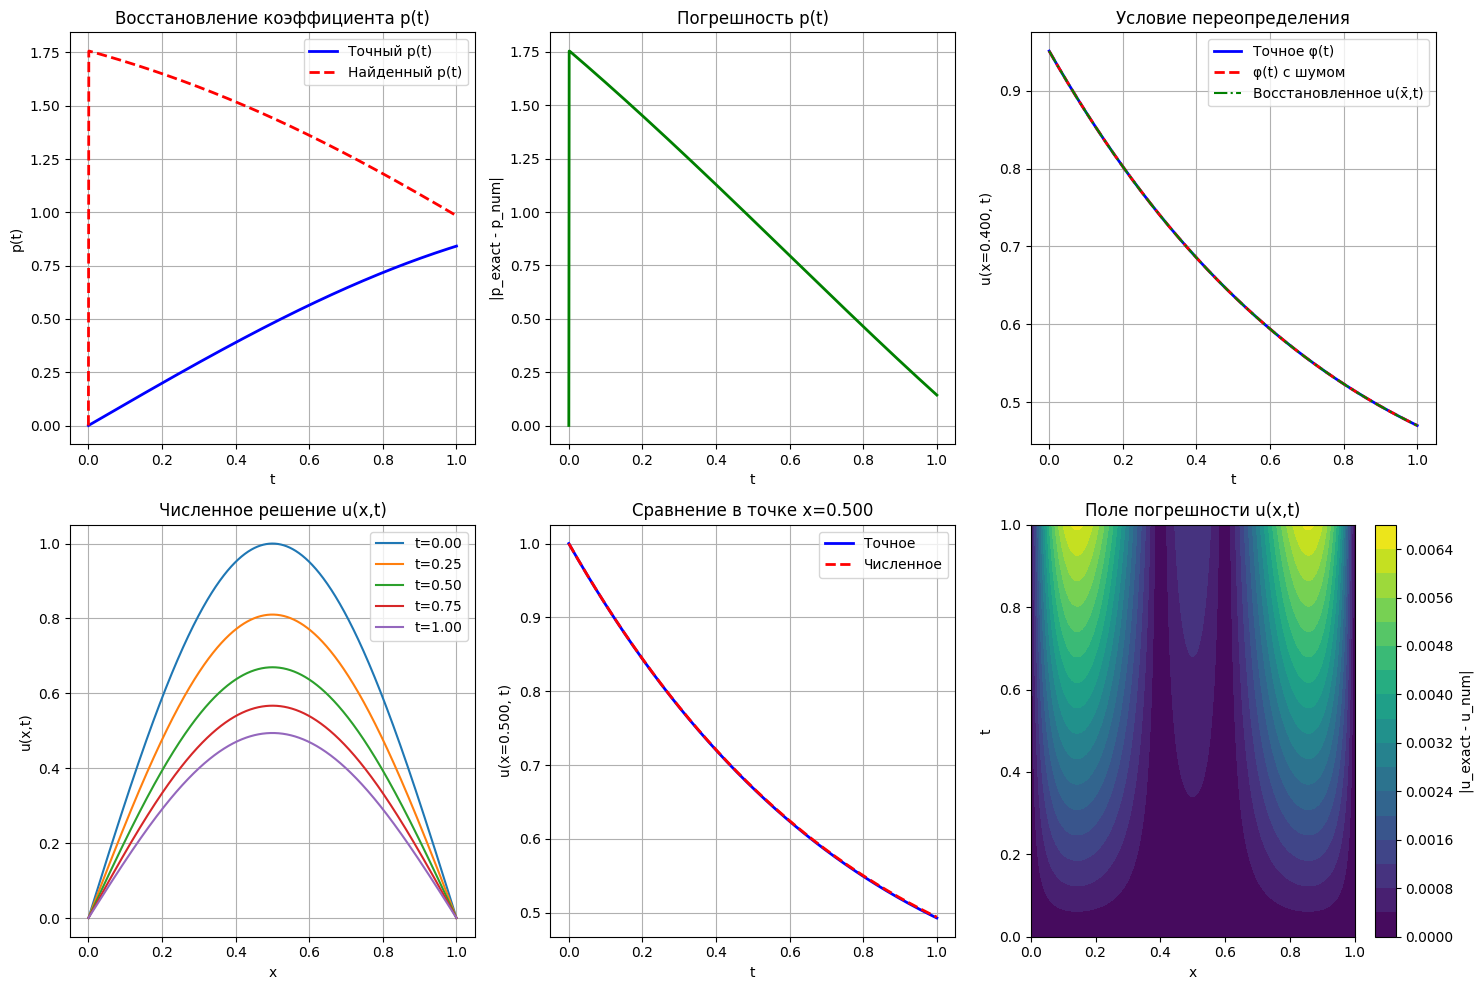

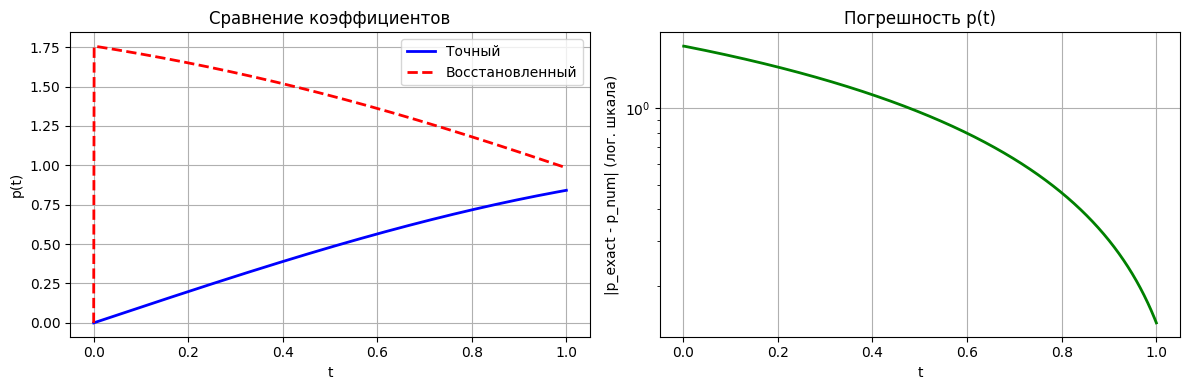


Проверка условия переопределения:
  φ(0) = 0.951057, u0(x̄) = 0.951057
  φ(0.5) = 0.636845, y[500,400] = 0.636845
  φ(1.0) = 0.469874, y[1000,400] = 0.469874


In [58]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import solve_banded

# ============================================================
# 1. Задание точных функций (для тестирования)
# ============================================================

# Выбираем точное решение и p(t) для генерации синтетических данных
# Это нужно для проверки работоспособности метода

def exact_u(x, t):
    """Точное решение (выбираем любое, удовлетворяющее граничным условиям)"""
    return np.sin(np.pi * x) * np.exp(-t) + 0.5 * x * (1 - x) * t

def exact_p(t):
    """Точный коэффициент (для генерации данных)"""
    return np.sin(t) #np.cos(2 * np.pi * t) * 0.5 + 1.0

def exact_mu1(t):
    """Граничное условие слева: u(0,t)"""
    return exact_u(0, t)

def exact_mu2(t):
    """Граничное условие справа: u(l,t)"""
    return exact_u(1, t)

def exact_u0(x):
    """Начальное условие: u(x,0)"""
    return exact_u(x, 0)

def exact_phi(t, x_bar):
    """Условие переопределения: u(x_bar, t)"""
    return exact_u(x_bar, t)

# ============================================================
# 2. Параметры задачи
# ============================================================

l = 1.0                 # длина интервала по x
T = 1.0                 # конечное время
N = 1000                 # количество шагов по пространству
J = 1000                 # количество шагов по времени
x_bar = 0.4             # точка переопределения (должна быть внутри интервала)

# Сетки
h = l / N               # шаг по пространству
tau = T / J             # шаг по времени

x = np.linspace(0, l, N+1)
t = np.linspace(0, T, J+1)

# Индекс точки переопределения
n = int(np.round(x_bar / h))
x_bar_actual = x[n]     # фактическая точка на сетке
print(f"Точка переопределения: x_bar = {x_bar}, ближайший узел: {x_bar_actual}, индекс n = {n}")

# ============================================================
# 3. Генерация точных данных (для тестирования)
# ============================================================

# Точное решение на сетке (для сравнения)
U_exact = np.zeros((J+1, N+1))
for j in range(J+1):
    for i in range(N+1):
        U_exact[j, i] = exact_u(x[i], t[j])

# Граничные и начальные условия
mu1 = np.array([exact_mu1(t[j]) for j in range(J+1)])
mu2 = np.array([exact_mu2(t[j]) for j in range(J+1)])
u0 = np.array([exact_u0(x[i]) for i in range(N+1)])

# Условие переопределения (точное)
phi_exact = np.array([exact_phi(t[j], x_bar_actual) for j in range(J+1)])

# Добавляем шум в условие переопределения (для реалистичности)
noise_level = 0.001
np.random.seed(42)
phi = phi_exact #+ noise_level * np.random.randn(J+1)
phi[0] = u0[n]  # гарантируем совпадение в начальный момент




# ============================================================
# 4. Решение обратной задачи
# ============================================================

# Параметр r = 2h^2/tau
r = 2 * h**2 / tau

# Массивы для решения
y = np.zeros((J+1, N+1))  # численное решение
y[0, :] = u0               # начальное условие

# Массивы для z и v (на текущем слое)
z = np.zeros(N+1)
v = np.zeros(N+1)

# Массив для найденного p(t)
p_numerical = np.zeros(J+1)
p_numerical[0] = 0.0  # начальное значение (можно любое)

# Коэффициенты для трехдиагональной матрицы (ленточное представление)
# Для системы au_{i-1} + bu_i + cu_{i+1} = d
# В ленточном виде: [c, b, a] (верхняя диагональ, главная, нижняя)

# Основной цикл по времени
for j in range(1, J+1):
    # --------------------------------------------------------
    # Шаг 1: Решаем систему для z (10)
    # a_i * z_{i-1} - c_bar_i * z_i + b_i * z_{i+1} + d_bar_i = 0
    # --------------------------------------------------------
    
    # Формируем правую часть d_bar_i
    d_bar = np.zeros(N+1)
    for i in range(1, N):
        # y_i^{j-1} - известное решение на предыдущем слое
        d_bar[i] = r * y[j-1, i] - (y[j-1, i+1] - 2*y[j-1, i] + y[j-1, i-1])
    
    # Граничные условия для z
    z[0] = mu1[j]
    z[N] = mu2[j]
    
    # Формируем трехдиагональную матрицу для z
    # Главная диагональ: -c_bar_i = -(2 + r)
    # Нижняя диагональ: a_i = 1
    # Верхняя диагональ: b_i = 1
    
    # Ленточное представление: [нижняя, главная, верхняя]
    ab_z = np.zeros((3, N-1))  # для внутренних узлов i=1..N-1
    
    # Главная диагональ (с обратным знаком, так как в уравнении -c_bar_i * z_i)
    ab_z[1, :] = -(2 + r)  # -c_bar_i
    
    # Нижняя диагональ (a_i)
    ab_z[0, 1:] = 1.0      # для i=2..N-1, a_i соответствует z_{i-1}
    
    # Верхняя диагональ (b_i)
    ab_z[2, :-1] = 1.0      # для i=1..N-2, b_i соответствует z_{i+1}
    
    # Правая часть для внутренних узлов
    rhs_z = -d_bar[1:N]     # минус, так как переносим в правую часть
    
    # Корректировка для первого и последнего уравнения с учетом граничных условий
    rhs_z[0] -= ab_z[0, 0] * z[0]      # вычитаем a_1 * z_0
    rhs_z[-1] -= ab_z[2, -1] * z[N]    # вычитаем b_{N-1} * z_N
    
    # Решаем систему для внутренних узлов
    z_inner = solve_banded((1, 1), ab_z, rhs_z)
    z[1:N] = z_inner
    
    # --------------------------------------------------------
    # Шаг 2: Решаем систему для v (11)
    # a_i * v_{i-1} - (c_bar_i + h^2 * p^{j-1}) * v_i + b_i * v_{i+1} + h^2 * y_i^{j-1} = 0
    # --------------------------------------------------------
    
    # Формируем правую часть для v
    d_v = np.zeros(N+1)
    for i in range(1, N):
        d_v[i] = -h**2 * y[j-1, i]  # знак минус, так как переносим в правую часть
    
    # Граничные условия для v
    v[0] = 0.0
    v[N] = 0.0
    
    # Формируем трехдиагональную матрицу для v
    ab_v = np.zeros((3, N-1))
    
    # Главная диагональ: -(c_bar_i + h^2 * p^{j-1}) = -(2 + r + h^2 * p^{j-1})
    ab_v[1, :] = -(2 + r + h**2 * p_numerical[j-1])
    
    # Нижняя диагональ (a_i)
    ab_v[0, 1:] = 1.0
    
    # Верхняя диагональ (b_i)
    ab_v[2, :-1] = 1.0
    
    # Правая часть
    rhs_v = -d_v[1:N]  # минус, так как переносим в правую часть
    
    # Корректировка с учетом граничных условий
    rhs_v[0] -= ab_v[0, 0] * v[0]   # v_0 = 0, так что ничего не меняется
    rhs_v[-1] -= ab_v[2, -1] * v[N] # v_N = 0
    
    # Решаем систему
    v_inner = solve_banded((1, 1), ab_v, rhs_v)
    v[1:N] = v_inner
    
    # --------------------------------------------------------
    # Шаг 3: Находим p^j из условия переопределения (12)
    # y_n^j = z_n + p^j * v_n = phi_j
    # --------------------------------------------------------
    
    if abs(v[n]) > 1e-12:  # избегаем деления на ноль
        p_numerical[j] = (phi[j] - z[n]) / v[n]
    else:
        p_numerical[j] = p_numerical[j-1]  # если v_n = 0, берем предыдущее значение
        print(f"Предупреждение: v[{n}] = 0 на шаге {j}")
    
    # --------------------------------------------------------
    # Шаг 4: Находим решение y^j = z + p^j * v
    # --------------------------------------------------------
    y[j, :] = z + p_numerical[j] * v

# ============================================================
# 5. Результаты
# ============================================================

print("\n" + "="*60)
print("РЕЗУЛЬТАТЫ")
print("="*60)

# Сравнение точного и найденного p(t)
p_exact_values = np.array([exact_p(t[j]) for j in range(J+1)])

# Вычисляем относительную погрешность
error_p = np.abs(p_numerical - p_exact_values)
rel_error_p = error_p / (np.abs(p_exact_values) + 1e-12)
mean_rel_error = np.mean(rel_error_p[1:])  # пропускаем начальный момент

print(f"Средняя относительная погрешность определения p(t): {mean_rel_error:.6f}")
print(f"Максимальная погрешность: {np.max(error_p[1:]):.6f}")

# Сравнение решения u(x,t)
error_u = np.abs(y - U_exact)
max_error_u = np.max(error_u)
mean_error_u = np.mean(error_u)

print(f"Максимальная погрешность решения u(x,t): {max_error_u:.6f}")
print(f"Средняя погрешность решения u(x,t): {mean_error_u:.6f}")

# ============================================================
# 6. Визуализация
# ============================================================

plt.figure(figsize=(15, 10))

# График 1: Найденный p(t) vs точный p(t)
plt.subplot(2, 3, 1)
plt.plot(t, p_exact_values, 'b-', linewidth=2, label='Точный p(t)')
plt.plot(t, p_numerical, 'r--', linewidth=2, label='Найденный p(t)')
plt.xlabel('t')
plt.ylabel('p(t)')
plt.title('Восстановление коэффициента p(t)')
plt.legend()
plt.grid(True)

# График 2: Погрешность p(t)
plt.subplot(2, 3, 2)
plt.plot(t, error_p, 'g-', linewidth=2)
plt.xlabel('t')
plt.ylabel('|p_exact - p_num|')
plt.title('Погрешность p(t)')
plt.grid(True)

# График 3: Условие переопределения
plt.subplot(2, 3, 3)
plt.plot(t, phi_exact, 'b-', linewidth=2, label='Точное φ(t)')
plt.plot(t, phi, 'r--', linewidth=2, label='φ(t) с шумом')
plt.plot(t, y[:, n], 'g-.', markersize=3, label='Восстановленное u(x̄,t)')
plt.xlabel('t')
plt.ylabel(f'u(x={x_bar_actual:.3f}, t)')
plt.title('Условие переопределения')
plt.legend()
plt.grid(True)

# График 4: Решение в разные моменты времени
plt.subplot(2, 3, 4)
times_to_plot = [0, J//4, J//2, 3*J//4, J]
for j_idx in times_to_plot:
    plt.plot(x, y[j_idx, :], label=f't={t[j_idx]:.2f}')
plt.xlabel('x')
plt.ylabel('u(x,t)')
plt.title('Численное решение u(x,t)')
plt.legend()
plt.grid(True)

# График 5: Сравнение с точным решением в средней точке
plt.subplot(2, 3, 5)
mid_x = N//2
plt.plot(t, U_exact[:, mid_x], 'b-', linewidth=2, label='Точное')
plt.plot(t, y[:, mid_x], 'r--', linewidth=2, label='Численное')
plt.xlabel('t')
plt.ylabel(f'u(x={x[mid_x]:.3f}, t)')
plt.title(f'Сравнение в точке x={x[mid_x]:.3f}')
plt.legend()
plt.grid(True)

# График 6: Профиль погрешности u(x,t)
plt.subplot(2, 3, 6)
plt.contourf(x, t, error_u, levels=20, cmap='viridis')
plt.colorbar(label='|u_exact - u_num|')
plt.xlabel('x')
plt.ylabel('t')
plt.title('Поле погрешности u(x,t)')

plt.tight_layout()
plt.show()

# Дополнительный график: эволюция p(t)
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(t, p_exact_values, 'b-', linewidth=2, label='Точный')
plt.plot(t, p_numerical, 'r--', linewidth=2, label='Восстановленный')
plt.xlabel('t')
plt.ylabel('p(t)')
plt.title('Сравнение коэффициентов')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.semilogy(t[1:], error_p[1:], 'g-', linewidth=2)
plt.xlabel('t')
plt.ylabel('|p_exact - p_num| (лог. шкала)')
plt.title('Погрешность p(t)')
plt.grid(True)

plt.tight_layout()
plt.show()

print("\nПроверка условия переопределения:")
print(f"  φ(0) = {phi[0]:.6f}, u0(x̄) = {u0[n]:.6f}")
print(f"  φ(0.5) = {phi[J//2]:.6f}, y[{J//2},{n}] = {y[J//2, n]:.6f}")
print(f"  φ(1.0) = {phi[J]:.6f}, y[{J},{n}] = {y[J, n]:.6f}")

Создание анимации...
Анимация сохранена как 'solution.gif'


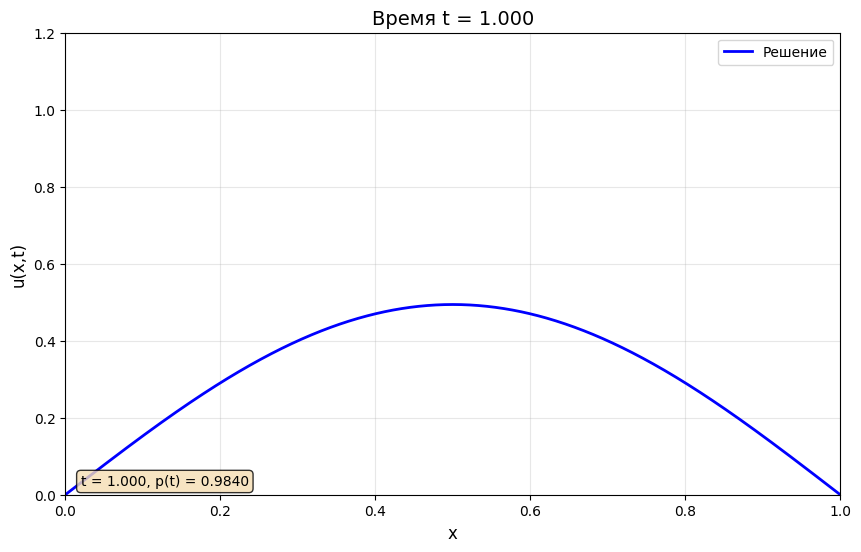

In [46]:
import matplotlib.animation as animation
fig, ax = plt.subplots(figsize=(10, 6))

# Начальный график
line, = ax.plot(x, y[0], 'b-', linewidth=2, label='Решение')
ax.set_xlim(0, 1)
ax.set_ylim(y.min(), y.max()*1.2)  # Фиксируем пределы для наглядности
ax.set_xlabel('x', fontsize=12)
ax.set_ylabel('u(x,t)', fontsize=12)
ax.set_title(f'Время t = 0.00', fontsize=14)
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3)

# Добавим информацию о параметрах
text_info = ax.text(0.02, 0.02, f'N={N}, J={J}', transform=ax.transAxes, 
                   fontsize=10, bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.8))

def update(frame):
    line.set_ydata(y[frame])
    ax.set_title(f'Время t = {t[frame]:.3f}', fontsize=14)
    
    # Обновляем информацию о текущем времени и значении p(t)
    text_info.set_text(f't = {t[frame]:.3f}, p(t) = {p_numerical[frame]:.4f}')
    
    return line, text_info

# Создание анимации
frame_step = 25  # Показываем каждый 5-й кадр для плавности
frames = range(0, J+1, frame_step)
ani = animation.FuncAnimation(fig, update, frames=frames, interval=50, blit=True)

# Сохраняем анимацию
print("Создание анимации...")
ani.save('solution.gif', writer='pillow', fps=10, dpi=100)
print("Анимация сохранена как 'solution.gif'")

h = 0.016667, tau = 0.005000, r = 0.111111
x_bar = 0.500000, индекс n = 30
estimated p(0) from phi(t): 0.006010
max |y(x_bar,t) - phi(t)| = 0.000e+00
max |p_rec(t) - p_true(t)| = 6.010e-03
max |u_rec(x,t) - u_ref(x,t)| = 1.110e-15


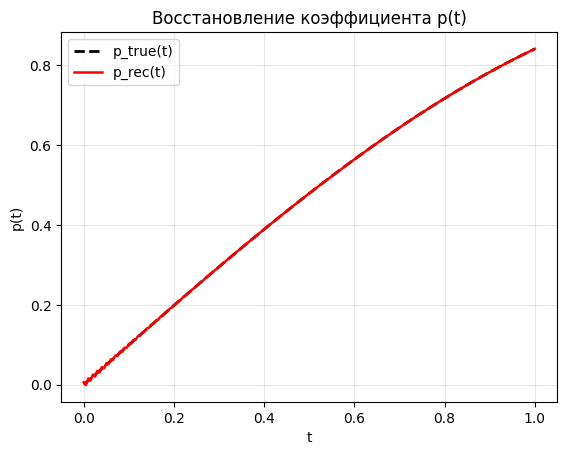

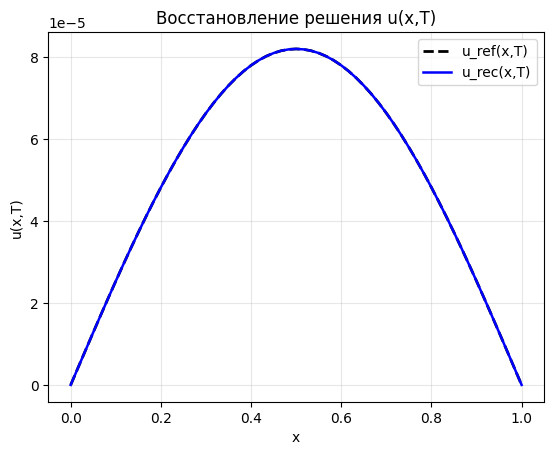

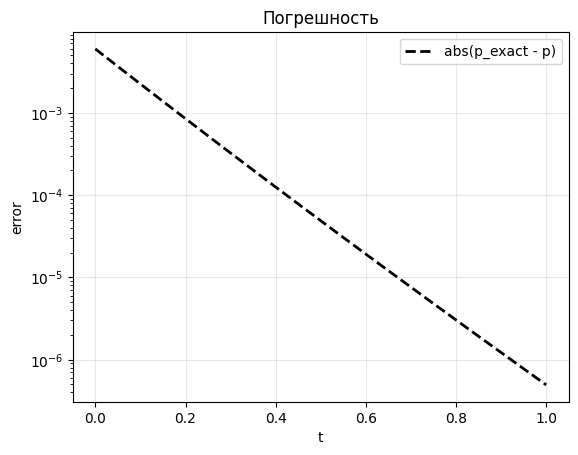

In [65]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================================================
# ПАРАМЕТРЫ
# ==========================================================
l = 1.0
t_max = 1.0
N = 60
J = 200
x_bar = 0.5

h = l / N
tau = t_max / J
r = 2.0 * h**2 / tau

x = np.linspace(0.0, l, N + 1)
t = np.linspace(0.0, t_max, J + 1)

n = int(round(x_bar / h))
if n <= 0 or n >= N:
    raise ValueError("x_bar должен быть внутренним узлом: 0 < n < N")

eps = 1e-12

print(f"h = {h:.6f}, tau = {tau:.6f}, r = {r:.6f}")
print(f"x_bar = {x[n]:.6f}, индекс n = {n}")


# ==========================================================
# ИСХОДНЫЕ ДАННЫЕ
# ==========================================================
def u0(x_val):
    return np.sin(np.pi * x_val)


def mu1(t_val):
    return 0.0


def mu2(t_val):
    return 0.0


def p_true(t_val):
    return np.sin(t_val) #1.5 + 0.4 * np.sin(2.0 * np.pi * t_val)


def thomas(lower, diag, upper, rhs):
    """Решение трехдиагональной системы."""
    n_sys = rhs.size
    c_star = np.zeros(n_sys)
    d_star = np.zeros(n_sys)

    c_star[0] = upper[0] / diag[0] if n_sys > 1 else 0.0
    d_star[0] = rhs[0] / diag[0]

    for i in range(1, n_sys):
        denom = diag[i] - lower[i] * c_star[i - 1]
        c_star[i] = upper[i] / denom if i < n_sys - 1 else 0.0
        d_star[i] = (rhs[i] - lower[i] * d_star[i - 1]) / denom

    sol = np.zeros(n_sys)
    sol[-1] = d_star[-1]
    for i in range(n_sys - 2, -1, -1):
        sol[i] = d_star[i] - c_star[i] * sol[i + 1]
    return sol


# ==========================================================
# 1) ПРЯМАЯ ЗАДАЧА: ГЕНЕРАЦИЯ phi(t)
# ==========================================================
p_ref = p_true(t)
y_ref = np.zeros((N + 1, J + 1))
y_ref[:, 0] = u0(x)
y_ref[0, 0] = mu1(t[0])
y_ref[N, 0] = mu2(t[0])

for j in range(1, J + 1):
    y_prev = y_ref[:, j - 1]
    p_prev = p_ref[j - 1]
    p_cur = p_ref[j]

    size = N - 1
    lower = np.ones(size)
    diag = np.full(size, -(2.0 + r - h**2 * p_prev))
    upper = np.ones(size)
    lower[0] = 0.0
    upper[-1] = 0.0

    rhs = np.zeros(size)
    for i in range(1, N):
        idx = i - 1
        d_bar = r * y_prev[i] + (y_prev[i + 1] - 2.0 * y_prev[i] + y_prev[i - 1])
        rhs[idx] = -(d_bar + h**2 * p_cur * y_prev[i])

    rhs[0] -= mu1(t[j])
    rhs[-1] -= mu2(t[j])

    y_inner = thomas(lower, diag, upper, rhs)

    y_ref[0, j] = mu1(t[j])
    y_ref[N, j] = mu2(t[j])
    y_ref[1:N, j] = y_inner

phi = y_ref[n, :].copy()

# p(0) из условия переопределения:
# phi'(0) = u_xx(x_bar, 0) + p(0) * u0(x_bar)
u0_grid = u0(x)
u0_xx_bar = (u0_grid[n + 1] - 2.0 * u0_grid[n] + u0_grid[n - 1]) / h**2
if J >= 2:
    phi_t0 = (-3.0 * phi[0] + 4.0 * phi[1] - phi[2]) / (2.0 * tau)
else:
    phi_t0 = (phi[1] - phi[0]) / tau

if abs(u0_grid[n]) < eps:
    raise ValueError("Невозможно определить p(0): u0(x_bar) близко к нулю")

p0_est = (phi_t0 - u0_xx_bar) / u0_grid[n]
print(f"estimated p(0) from phi(t): {p0_est:.6f}")


# ==========================================================
# 2) ОБРАТНАЯ ЗАДАЧА: ВОССТАНОВЛЕНИЕ p(t), u(x,t)
# ==========================================================
y = np.zeros((N + 1, J + 1))
p = np.zeros(J + 1)

y[:, 0] = u0_grid
y[0, 0] = mu1(t[0])
y[N, 0] = mu2(t[0])
p[0] = p0_est
for j in range(1, J + 1):
    y_prev = y[:, j - 1]
    p_prev = p[j - 1]

    size = N - 1
    lower = np.ones(size)
    diag = np.full(size, -(2.0 + r - h**2 * p_prev))
    upper = np.ones(size)
    lower[0] = 0.0
    upper[-1] = 0.0

    # Система для z^j
    rhs_z = np.zeros(size)
    for i in range(1, N):
        idx = i - 1
        d_bar = r * y_prev[i] + (y_prev[i + 1] - 2.0 * y_prev[i] + y_prev[i - 1])
        rhs_z[idx] = -d_bar

    rhs_z[0] -= mu1(t[j])
    rhs_z[-1] -= mu2(t[j])

    z = np.zeros(N + 1)
    z[0] = mu1(t[j])
    z[N] = mu2(t[j])
    z[1:N] = thomas(lower, diag, upper, rhs_z)

    # Система для v^j
    rhs_v = -h**2 * y_prev[1:N]
    v = np.zeros(N + 1)
    v[1:N] = thomas(lower, diag, upper, rhs_v)

    # Восстановление p^j
    if abs(v[n]) < eps:
        p[j] = p_prev
    else:
        p[j] = (phi[j] - z[n]) / v[n]

    # Восстановление y^j
    y[:, j] = z + p[j] * v
    y[0, j] = mu1(t[j])
    y[N, j] = mu2(t[j])


# ==========================================================
# КОНТРОЛЬ ТОЧНОСТИ
# ==========================================================
misfit_phi = np.max(np.abs(y[n, :] - phi))
err_p_max = np.max(np.abs(p - p_ref))
err_u_max = np.max(np.abs(y - y_ref))

print(f"max |y(x_bar,t) - phi(t)| = {misfit_phi:.3e}")
print(f"max |p_rec(t) - p_true(t)| = {err_p_max:.3e}")
print(f"max |u_rec(x,t) - u_ref(x,t)| = {err_u_max:.3e}")


# ==========================================================
# ГРАФИКИ
# ==========================================================
fig1 = plt.figure()
plt.plot(t, p_ref, "k--", lw=2, label="p_true(t)")
plt.plot(t, p, "r", lw=1.8, label="p_rec(t)")
plt.title("Восстановление коэффициента p(t)")
plt.xlabel("t")
plt.ylabel("p(t)")
plt.grid(True, alpha=0.3)
plt.legend()

fig2 = plt.figure()
plt.plot(x, y_ref[:, -1], "k--", lw=2, label="u_ref(x,T)")
plt.plot(x, y[:, -1], "b", lw=1.8, label="u_rec(x,T)")
plt.title("Восстановление решения u(x,T)")
plt.xlabel("x")
plt.ylabel("u(x,T)")
plt.grid(True, alpha=0.3)
plt.legend()

fig3 = plt.figure()
plt.semilogy(t, np.abs(p_ref - p), "k--", lw=2, label="abs(p_exact - p)")
plt.title("Погрешность")
plt.xlabel("t")
plt.ylabel("error")
plt.grid(True, alpha=0.3)
plt.legend()

if "agg" in plt.get_backend().lower():
    fig1.savefig("p_recovery.png", dpi=150, bbox_inches="tight")
    fig2.savefig("u_recovery.png", dpi=150, bbox_inches="tight")
    fig3.savefig("error.png", dpi=150, bbox_inches="tight")
    print("Графики сохранены: p_recovery.png, u_recovery.png")
else:
    plt.show()
    
